LINEAR REGRESSION

In [11]:
#Importing the relevant modules
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt

In [12]:
#Adjusting the granularity of the reporting
pd.options.display.max_rows = 10
pd.options.display.float_format = "{:.1f}".format

In [13]:
#Importing the dataset
training_df = pd.read_csv("https://download.mlcc.google.com/mledu-datasets/california_housing_train.csv")

#Scaling the label
training_df["median_house_value"]/=1000.0

#Printting the first of the pandas DataFrame
training_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.3,34.2,15.0,5612.0,1283.0,1015.0,472.0,1.5,66.9
1,-114.5,34.4,19.0,7650.0,1901.0,1129.0,463.0,1.8,80.1
2,-114.6,33.7,17.0,720.0,174.0,333.0,117.0,1.7,85.7
3,-114.6,33.6,14.0,1501.0,337.0,515.0,226.0,3.2,73.4
4,-114.6,33.6,20.0,1454.0,326.0,624.0,262.0,1.9,65.5


In [14]:
training_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.0,17000.0,17000.0,17000.0,17000.0,17000.0,17000.0,17000.0,17000.0
mean,-119.6,35.6,28.6,2643.7,539.4,1429.6,501.2,3.9,207.3
std,2.0,2.1,12.6,2179.9,421.5,1147.9,384.5,1.9,116.0
min,-124.3,32.5,1.0,2.0,1.0,3.0,1.0,0.5,15.0
25%,-121.8,33.9,18.0,1462.0,297.0,790.0,282.0,2.6,119.4
50%,-118.5,34.2,29.0,2127.0,434.0,1167.0,409.0,3.5,180.4
75%,-118.0,37.7,37.0,3151.2,648.2,1721.0,605.2,4.8,265.0
max,-114.3,42.0,52.0,37937.0,6445.0,35682.0,6082.0,15.0,500.0


In [45]:
#Define the function that building a model
def build_model(my_learning_rate):
    '''Creating and compileing a simple linear regression model.'''
    
    #Most simple tf.models were sequential.
    model = tf.keras.models.Sequential()

    #The topography of a simple linear regression model is a single node in a single layer.
    model.add(tf.keras.layers.Dense(units=1,
                                    input_shape=(1,)))

    #Compile the model topograpy into code that TensorFlow can efficiently execute.
    #Configre training to minimize the models mean squared error.
    model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=my_learning_rate),
                 loss="mean_squared_error",
                 metrics=[tf.keras.metrics.RootMeanSquaredError()])
    return model


In [50]:
#Define the function that trainine a model
def train_model(model, df, feature, label, epochs, batch_size):
    '''Train the model by feeding it data.'''

    #Feed the model the feature and the label.
    #The model will train for the specified number of epochs 
    history = model.fit(x=df[feature],
                       y=df[label],
                       batch_size=batch_size,
                       epochs=epochs)

    #Gather the trained models weight and bias.
    trained_weight = model.get_weights()[0][0]
    trained_bias = model.get_weights()[1]

    #The list of epochs is stored separately from the rest of history.
    epochs = history.epoch

    #Isolate the error for each epoch.
    hist = pd.DataFrame(history.history)

    #To tarck the progression of training , wr're going to take a snapshot of the model's 
    #root mean squared error at each epoch.
    rmse = hist["root_mean_squared_error"]

    return trained_weight, trained_bias, epochs, rmse

    print("Defined the build_model and train__model functions")

In [60]:
#Define the plotting function
def plot_the_model(trained_weight, trained_bias, feature, label):
    '''Plot the trained model against 200 random training examples.'''

    #Labels the axes.
    plt.xlabel(feature)
    plt.ylabel(label)

    #Create a scatter plot from 200 random points of the dataset.
    random_examples = training_df.sample(n=200)
    plt.scatter(random_examples[feature], random_examples[label])

    #Create a red line representing the model. 
    #The red line starts at coordinates (x0, y0) and ends at coordinates (x1, y1).
    x0 = 0
    y0 = trained_bias
    x1 = random_examples[feature].max()
    y1 = trained_bias + (trained_weight * x1)
    plt.plot([x0,x1],[y0,y1],c='r')

    # render the scstter plot and the red line.
    plt.show()
    

In [61]:

def plot_the_loss_curve(epochs, rmse):
  """Plot a curve of loss vs. epoch."""

  plt.figure()
  plt.xlabel("Epoch")
  plt.ylabel("Root Mean Squared Error")

  plt.plot(epochs, rmse, label="Loss")
  plt.legend()
  plt.ylim([rmse.min()*0.97, rmse.max()])
  plt.show()  

print("Defined the plot_the_model and plot_the_loss_curve functions.")

Defined the plot_the_model and plot_the_loss_curve functions.


Epoch 1/30


C:\Users\jetti\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


567/567 ━━━━━━━━━━━━━━━━━━━━ 1s 790us/step - loss: 92860.5234 - root_mean_squared_error: 280.4968
Epoch 2/30
567/567 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step - loss: 27226.8730 - root_mean_squared_error: 164.9682
Epoch 3/30
567/567 ━━━━━━━━━━━━━━━━━━━━ 0s 802us/step - loss: 27733.3848 - root_mean_squared_error: 166.4908
Epoch 4/30
567/567 ━━━━━━━━━━━━━━━━━━━━ 1s 922us/step - loss: 25759.4414 - root_mean_squared_error: 160.4405
Epoch 5/30
567/567 ━━━━━━━━━━━━━━━━━━━━ 0s 781us/step - loss: 25614.4492 - root_mean_squared_error: 160.0404
Epoch 6/30
567/567 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step - loss: 24565.1562 - root_mean_squared_error: 156.7240
Epoch 7/30
567/567 ━━━━━━━━━━━━━━━━━━━━ 0s 774us/step - loss: 24734.2012 - root_mean_squared_error: 157.2365
Epoch 8/30
567/567 ━━━━━━━━━━━━━━━━━━━━ 0s 785us/step - loss: 22616.3770 - root_mean_squared_error: 150.2624
Epoch 9/30
567/567 ━━━━━━━━━━━━━━━━━━━━ 0s 774us/step - loss: 23115.0391 - root_mean_squared_error: 152.0259
Epoch 10/30
567/567 ━━━━━━━━━━

C:\Users\jetti\AppData\Local\Temp\ipykernel_812\2560251290.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("\n The learned weight for your model  is %.4f" % weight)
C:\Users\jetti\AppData\Local\Temp\ipykernel_812\2560251290.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("The learned bias for the your model is %.4f\n" % bias)


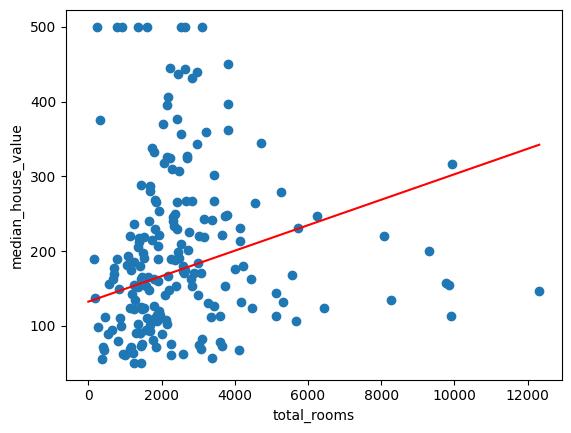

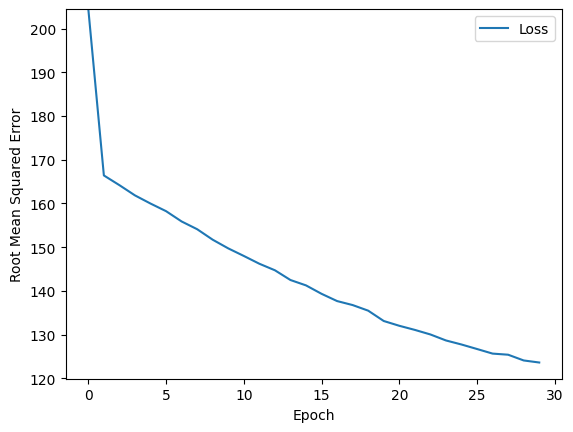

In [62]:
# The following were the variables and hyperparameters.
learning_rate = 0.01
epochs = 30
batch_size = 30

#Specify the features and the label
my_feature = "total_rooms"      #The total  no. of rooms on a specify city block.
my_label = "median_house_value" #The median value of a house on a specific city block.
#That is, you're going to create a model that predicts house value based solely on total_rooms.  


#Discard any pre-existing version of the model.
my_model = None

#Invoke the functions.
my_model = build_model(learning_rate)
weight, bias, epochs, rmse = train_model(my_model, training_df, my_feature, my_label,epochs, batch_size)

print("\n The learned weight for your model  is %.4f" % weight)
print(" The learned bias for the your model is %.4f\n" % bias)

plot_the_model(weight, bias, my_feature, my_label)
plot_the_loss_curve(epochs, rmse)

In [66]:
def predict_house_values(n, feature, label):
    """Predict house values based on a feature"""

    batch = training_df[feature][10000:10000 + n]
    predicted_values = my_model.predict_on_batch(x=batch)

    print("feature       label           predicted")
    print("  value       value           value")
    print("              in thousands$   in thousand$")
    print("-------------------------------------------")
    for i in range(n):
        print("%5.0f %6.0f %15.0f" % (training_df[feature][10000 + 1],
                                     training_df[label][10000 + i]
                                     ,predicted_values[i][0]))

In [68]:
predict_house_values(10, my_feature, my_label)

feature       label           predicted
  value       value           value
              in thousands$   in thousand$
-------------------------------------------
 3400     53             166
 3400     92             190
 3400     69             195
 3400     62             170
 3400     80             173
 3400    295             229
 3400    500             189
 3400    342             176
 3400    118             156
 3400    128             191


Epoch 1/18


C:\Users\jetti\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5667/5667 ━━━━━━━━━━━━━━━━━━━━ 5s 779us/step - loss: 41271.3477 - root_mean_squared_error: 198.6377
Epoch 2/18
5667/5667 ━━━━━━━━━━━━━━━━━━━━ 4s 779us/step - loss: 20531.1289 - root_mean_squared_error: 143.2360
Epoch 3/18
5667/5667 ━━━━━━━━━━━━━━━━━━━━ 4s 780us/step - loss: 18570.9121 - root_mean_squared_error: 136.2365
Epoch 4/18
5667/5667 ━━━━━━━━━━━━━━━━━━━━ 4s 781us/step - loss: 18047.9180 - root_mean_squared_error: 134.3251
Epoch 5/18
5667/5667 ━━━━━━━━━━━━━━━━━━━━ 4s 779us/step - loss: 17956.5762 - root_mean_squared_error: 133.9880
Epoch 6/18
5667/5667 ━━━━━━━━━━━━━━━━━━━━ 5s 813us/step - loss: 17588.5430 - root_mean_squared_error: 132.5892
Epoch 7/18
5667/5667 ━━━━━━━━━━━━━━━━━━━━ 5s 793us/step - loss: 18229.8594 - root_mean_squared_error: 135.0002
Epoch 8/18
5667/5667 ━━━━━━━━━━━━━━━━━━━━ 5s 793us/step - loss: 17705.6992 - root_mean_squared_error: 133.0364
Epoch 9/18
5667/5667 ━━━━━━━━━━━━━━━━━━━━ 5s 804us/step - loss: 18135.2910 - root_mean_squared_error: 134.6595
Epoch 10/18


C:\Users\jetti\AppData\Local\Temp\ipykernel_812\4204960582.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("\n The learned weight for your model  is %.4f" % weight)
C:\Users\jetti\AppData\Local\Temp\ipykernel_812\4204960582.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(" The learned bias for the your model is %.4f\n" % bias)


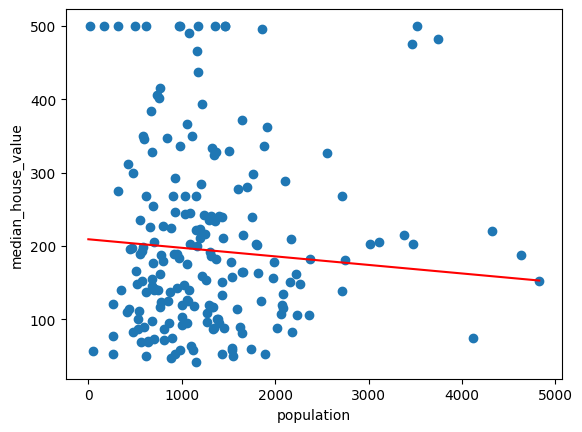

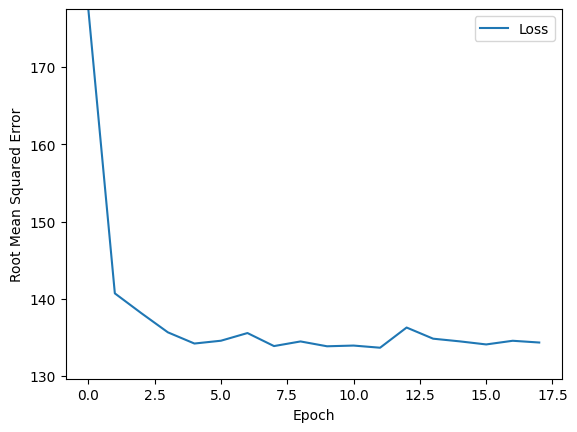

In [71]:
my_feature = "population"

# The following were the variables and hyperparameters.
learning_rate = 0.05
epochs = 18
batch_size = 3

my_model = build_model(learning_rate)
weight, bias, epochs, rmse = train_model(my_model, training_df, my_feature, my_label,epochs, batch_size)

print("\n The learned weight for your model  is %.4f" % weight)
print(" The learned bias for the your model is %.4f\n" % bias)

plot_the_model(weight, bias, my_feature, my_label)
plot_the_loss_curve(epochs, rmse)

In [74]:
predict_house_values(10, my_feature, my_label)

feature       label           predicted
  value       value           value
              in thousands$   in thousand$
-------------------------------------------
 3400     53             201
 3400     92             251
 3400     69             261
 3400     62             209
 3400     80             217
 3400    295             330
 3400    500             249
 3400    342             222
 3400    118             180
 3400    128             254


Epoch 1/30


C:\Users\jetti\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


567/567 ━━━━━━━━━━━━━━━━━━━━ 1s 791us/step - loss: 696034.2500 - root_mean_squared_error: 748.6979
Epoch 2/30
567/567 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step - loss: 27461.8184 - root_mean_squared_error: 165.6478
Epoch 3/30
567/567 ━━━━━━━━━━━━━━━━━━━━ 0s 784us/step - loss: 27078.6230 - root_mean_squared_error: 164.5363
Epoch 4/30
567/567 ━━━━━━━━━━━━━━━━━━━━ 0s 776us/step - loss: 27072.2324 - root_mean_squared_error: 164.4507
Epoch 5/30
567/567 ━━━━━━━━━━━━━━━━━━━━ 0s 773us/step - loss: 26890.7832 - root_mean_squared_error: 163.9264
Epoch 6/30
567/567 ━━━━━━━━━━━━━━━━━━━━ 1s 849us/step - loss: 25243.1523 - root_mean_squared_error: 158.8661
Epoch 7/30
567/567 ━━━━━━━━━━━━━━━━━━━━ 0s 793us/step - loss: 24345.6582 - root_mean_squared_error: 156.0226
Epoch 8/30
567/567 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step - loss: 24286.0566 - root_mean_squared_error: 155.7905
Epoch 9/30
567/567 ━━━━━━━━━━━━━━━━━━━━ 0s 782us/step - loss: 22726.0781 - root_mean_squared_error: 150.7399
Epoch 10/30
567/567 ━━━━━━━━━

C:\Users\jetti\AppData\Local\Temp\ipykernel_812\3687596073.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("\n The learned weight for your model  is %.4f" % weight)
C:\Users\jetti\AppData\Local\Temp\ipykernel_812\3687596073.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(" The learned bias for the your model is %.4f\n" % bias)


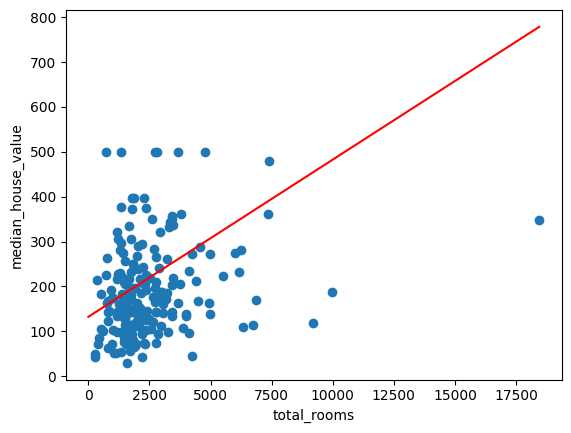

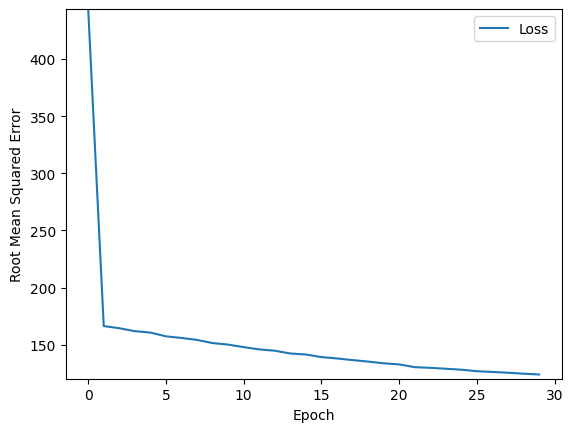

In [72]:
# The following were the variables and hyperparameters.
learning_rate = 0.01
epochs = 30
batch_size = 30

#Specify the features and the label
my_feature = "total_rooms"      #The total  no. of rooms on a specify city block.
my_label = "median_house_value" #The median value of a house on a specific city block.
#That is, you're going to create a model that predicts house value based solely on total_rooms.  


#Discard any pre-existing version of the model.
my_model = None

#Invoke the functions.
my_model = build_model(learning_rate)
weight, bias, epochs, rmse = train_model(my_model, training_df, my_feature, my_label,epochs, batch_size)

print("\n The learned weight for your model  is %.4f" % weight)
print(" The learned bias for the your model is %.4f\n" % bias)

plot_the_model(weight, bias, my_feature, my_label)
plot_the_loss_curve(epochs, rmse)

In [73]:
predict_house_values(10, my_feature, my_label)

feature       label           predicted
  value       value           value
              in thousands$   in thousand$
-------------------------------------------
 3400     53             201
 3400     92             251
 3400     69             261
 3400     62             209
 3400     80             217
 3400    295             330
 3400    500             249
 3400    342             222
 3400    118             180
 3400    128             254


Epoch 1/24


C:\Users\jetti\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


567/567 ━━━━━━━━━━━━━━━━━━━━ 1s 791us/step - loss: 46320.5234 - root_mean_squared_error: 214.8887
Epoch 2/24
567/567 ━━━━━━━━━━━━━━━━━━━━ 0s 792us/step - loss: 21129.8125 - root_mean_squared_error: 145.2791
Epoch 3/24
567/567 ━━━━━━━━━━━━━━━━━━━━ 0s 783us/step - loss: 15695.7129 - root_mean_squared_error: 125.1853
Epoch 4/24
567/567 ━━━━━━━━━━━━━━━━━━━━ 0s 776us/step - loss: 15544.6436 - root_mean_squared_error: 124.4952
Epoch 5/24
567/567 ━━━━━━━━━━━━━━━━━━━━ 0s 766us/step - loss: 14786.6494 - root_mean_squared_error: 121.4791
Epoch 6/24
567/567 ━━━━━━━━━━━━━━━━━━━━ 0s 772us/step - loss: 15497.6211 - root_mean_squared_error: 123.9905
Epoch 7/24
567/567 ━━━━━━━━━━━━━━━━━━━━ 1s 857us/step - loss: 13162.4951 - root_mean_squared_error: 114.6691
Epoch 8/24
567/567 ━━━━━━━━━━━━━━━━━━━━ 0s 778us/step - loss: 13466.7588 - root_mean_squared_error: 115.9998
Epoch 9/24
567/567 ━━━━━━━━━━━━━━━━━━━━ 0s 768us/step - loss: 14418.6963 - root_mean_squared_error: 120.0216
Epoch 10/24
567/567 ━━━━━━━━━━

C:\Users\jetti\AppData\Local\Temp\ipykernel_812\770346708.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("\n The learned weight for your model  is %.4f" % weight)
C:\Users\jetti\AppData\Local\Temp\ipykernel_812\770346708.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(" The learned bias for the your model is %.4f\n" % bias)


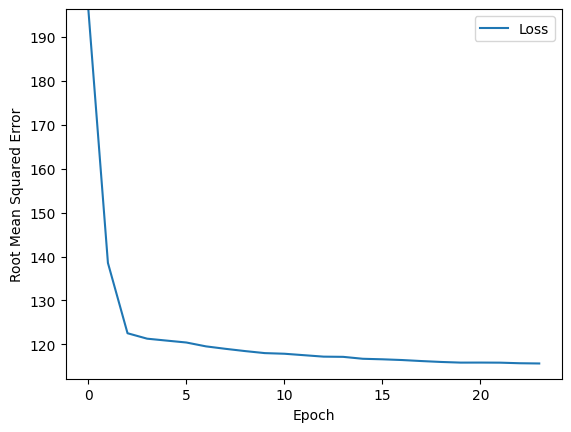

feature       label           predicted
  value       value           value
              in thousands$   in thousand$
-------------------------------------------
    2     53             190
    2     92             202
    2     69             196
    2     62             212
    2     80             187
    2    295             226
    2    500             211
    2    342             224
    2    118             290
    2    128             215
    2    187             225
    2     80             236
    2    112             226
    2     95             220
    2     69             212


In [75]:
#@title Double-click to view a possible solution to Task 4.

# Define a synthetic feature
training_df["rooms_per_person"] = training_df["total_rooms"] / training_df["population"]
my_feature = "rooms_per_person"

# Tune the hyperparameters.
learning_rate = 0.06
epochs = 24
batch_size = 30

# Don't change anything below this line.
my_model = build_model(learning_rate)
weight, bias, epochs, mae = train_model(my_model, training_df,
                                        my_feature, my_label,
                                        epochs, batch_size)


print("\n The learned weight for your model  is %.4f" % weight)
print(" The learned bias for the your model is %.4f\n" % bias)

plot_the_loss_curve(epochs, mae)

predict_house_values(15, my_feature, my_label)


In [76]:
#Generate a correlation matrix
training_df.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_person
longitude,1.0,-0.9,-0.1,0.0,0.1,0.1,0.1,-0.0,-0.0,-0.1
latitude,-0.9,1.0,0.0,-0.0,-0.1,-0.1,-0.1,-0.1,-0.1,0.1
housing_median_age,-0.1,0.0,1.0,-0.4,-0.3,-0.3,-0.3,-0.1,0.1,-0.1
total_rooms,0.0,-0.0,-0.4,1.0,0.9,0.9,0.9,0.2,0.1,0.1
total_bedrooms,0.1,-0.1,-0.3,0.9,1.0,0.9,1.0,-0.0,0.0,0.0
population,0.1,-0.1,-0.3,0.9,0.9,1.0,0.9,-0.0,-0.0,-0.1
households,0.1,-0.1,-0.3,0.9,1.0,0.9,1.0,0.0,0.1,-0.0
median_income,-0.0,-0.1,-0.1,0.2,-0.0,-0.0,0.0,1.0,0.7,0.2
median_house_value,-0.0,-0.1,0.1,0.1,0.0,-0.0,0.1,0.7,1.0,0.2
rooms_per_person,-0.1,0.1,-0.1,0.1,0.0,-0.1,-0.0,0.2,0.2,1.0
